In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# from bayes_opt import BayesianOptimization
from sklearn.preprocessing import label_binarize, MinMaxScaler


import warnings, json, math, os
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import plotly.graph_objects as go
from scipy.stats import norm

from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    roc_curve, auc, precision_recall_curve, f1_score, classification_report
)
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from scipy.spatial.distance import cdist


In [2]:
df = pd.read_csv("clean_df (1).csv")
df.shape

(2927, 117)

In [3]:
df.dtypes.value_counts()

,count
int64,62
bool,38
float64,17


Ignoring Boolean Features Before PCA

PCA (Principal Component Analysis) is a linear dimensionality reduction method that identifies directions (principal components) which maximize the variance in the dataset.
Since PCA relies on covariance and continuous variance, it is most meaningful for numerical features that can vary smoothly across a range of values.

Our dataset also contains several boolean features (values True/False, encoded as 1/0). These features do not represent continuous measurements but categorical states, which have only two possible values and very limited variance. Including them in PCA would lead to the following issues:

Distorted variance structure: Boolean features can artificially reduce or dominate certain directions of variance, depending on their frequency distribution.

Inconsistent interpretation: PCA assumes linear relationships between features, which is not appropriate for binary categorical data.

Uninformative components: Because boolean features have little continuous variability, they contribute minimally to the total variance that PCA tries to capture.

For these reasons, only the scaled numerical (int and float) features are used for PCA in this analysis.
This ensures that the resulting principal components genuinely reflect the continuous variance structure of the dataset and that the explained variance ratios are meaningful.

In [4]:
df.isna().sum().sort_values(ascending=False).head(10)


,0
MSZoning_encoded,2270
Lot Frontage,0
Lot Area,0
HouseStyle_MedianPrice,0
MS SubClass,0
Neighborhood_MedianPrice,0
Combo_PriceMean,0
Overall Qual,0
Overall Cond,0
Year Built,0


For some reason the first feature in the above list is corupted and presents mostly NaN values so for the sake of sanity it will be droped.

In [5]:
df.drop('MSZoning_encoded', axis=1, inplace=True)

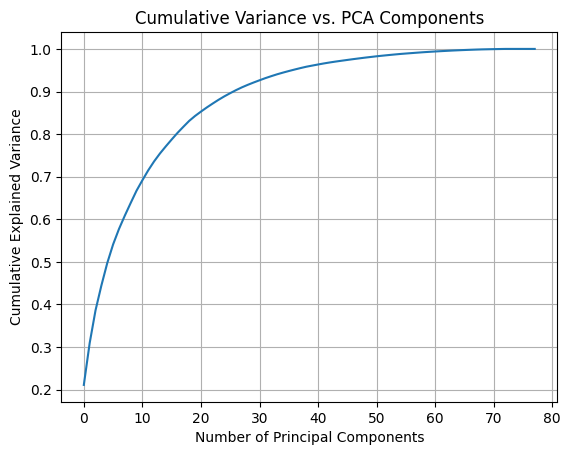

98% variance → 50 components
95% variance → 37 components
90% variance → 27 components
80% variance → 17 components


In [6]:
# Select numeric features (int + float)
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(df[numerical_cols])

# Run PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Explained variance
explained = pca.explained_variance_ratio_
cumulative = np.cumsum(explained)

# Plot
plt.plot(cumulative)
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Variance vs. PCA Components")
plt.grid(True)
plt.show()

# Find components for 98%, 95%, 90%, 80%
for target in [0.98, 0.95, 0.90, 0.80]:
    n = np.argmax(cumulative >= target) + 1
    print(f"{target*100:.0f}% variance → {n} components")
# Run PCA
pca = PCA()

In [7]:
targets = [0.80, 0.90, 0.95, 0.98]
reduced_datasets = {}

for target in targets:
    n = np.argmax(cumulative >= target) + 1
    pca = PCA(n_components=n)
    X_reduced = pca.fit_transform(X_scaled)
    reduced_datasets[target] = X_reduced
    print(f'Variance {target*100:.0f}% → {n} components → shape {X_reduced.shape}')

Variance 80% → 17 components → shape (2927, 17)
Variance 90% → 27 components → shape (2927, 27)
Variance 95% → 37 components → shape (2927, 37)
Variance 98% → 50 components → shape (2927, 50)


K-means clustering on each reduced dataset (according to explained variance). Uses elbow method (Within Cluster Sum of Squares) to find the optimal number of clusters (k)

Distortion values:
1 : 2.990937627176868
2 : 2.4342530174987673
3 : 2.1421583124455332
4 : 2.0609781395636175
5 : 1.9174280115246523
6 : 1.705378062003367
7 : 1.577609325848447
8 : 1.5103577544193352
9 : 1.4493650957125639


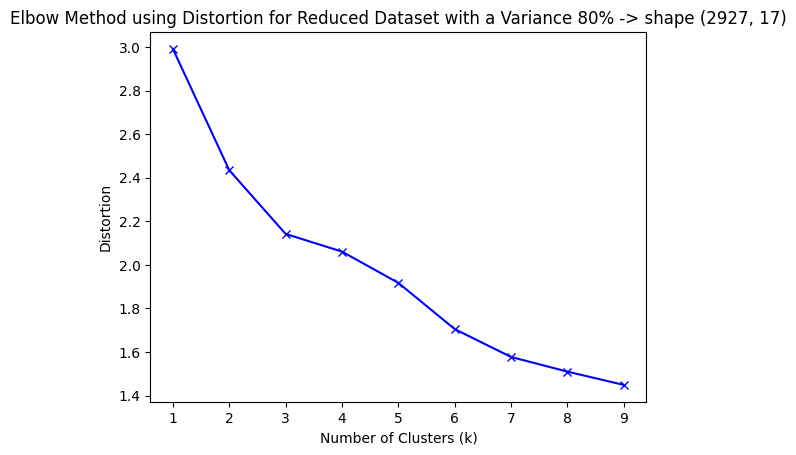

Distortion values:
1 : 3.3650444371209476
2 : 2.8076903299793448
3 : 2.5154012988443184
4 : 2.3898703784929936
5 : 2.2326756289295178
6 : 2.0527300509157804
7 : 1.9851927275470906
8 : 1.9170548656174469
9 : 1.8867556559261152


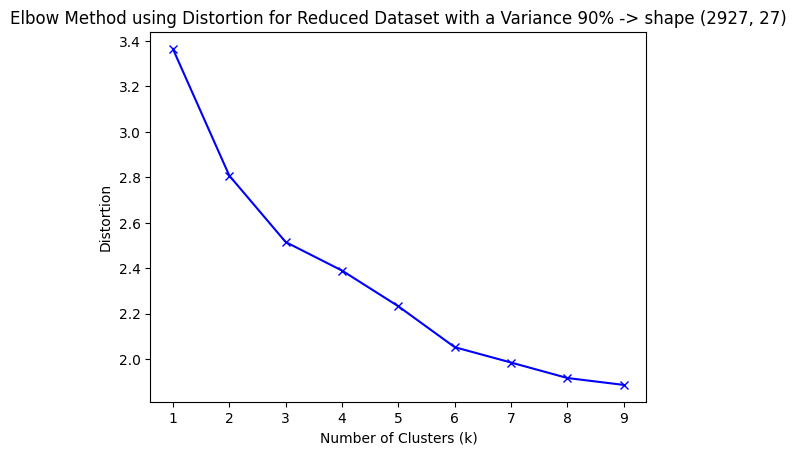

Distortion values:
1 : 3.5451194581324232
2 : 2.9876893715451542
3 : 2.695390055731305
4 : 2.525987908536937
5 : 2.390175425262281
6 : 2.238638172558865
7 : 2.1244095712208324
8 : 2.056196460055602
9 : 2.0372156123795637


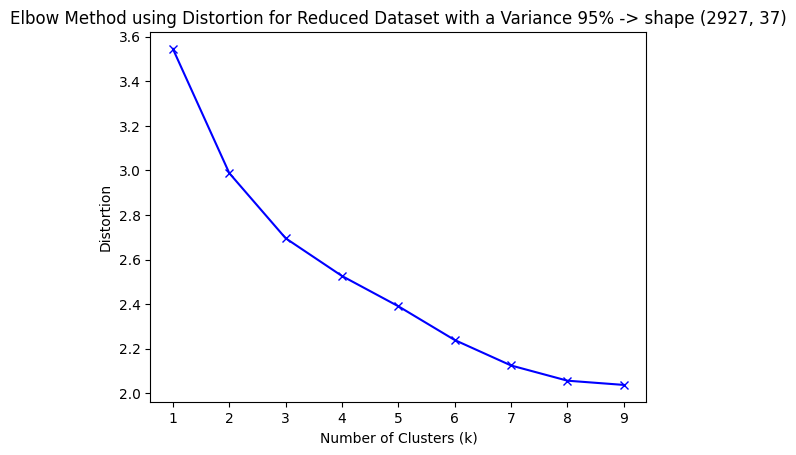

Distortion values:
1 : 3.655013544423185
2 : 3.0975188678187897
3 : 2.8717633414339074
4 : 2.6760340667620883
5 : 2.463980324173165
6 : 2.3417170850227853
7 : 2.257786177031996
8 : 2.2205725100294194
9 : 2.127331015188825


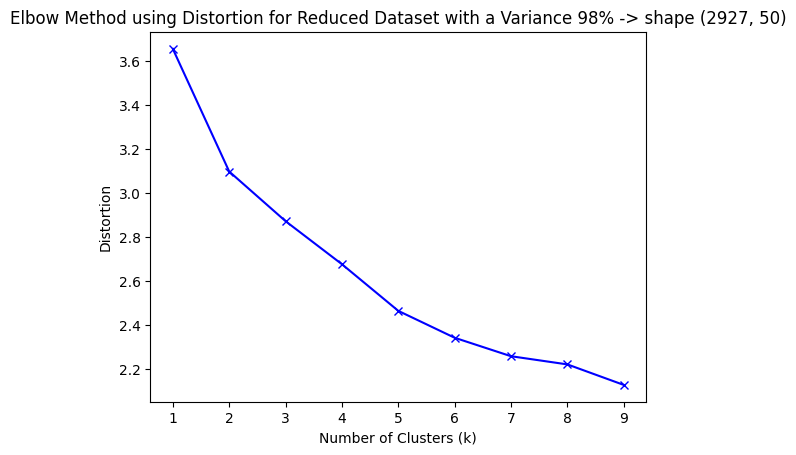

In [8]:

for target, X_reduced in reduced_datasets.items():
  distortions = []
  inertias = []
  mapping1 = {}
  mapping2 = {}
  K = range(1, 10)

  for k in K:
    model = KMeans(n_clusters=k, random_state=42).fit(X_reduced)

    distortions.append(sum(np.min(cdist(X_reduced, model.cluster_centers_, 'euclidean'), axis=1)**2) / X_reduced.shape[0])

    inertias.append(model.inertia_)
    mapping1[k] = distortions[-1]
    mapping2[k] = inertias[-1]

  print("Distortion values:")
  for key, val in mapping1.items():
      print(f'{key} : {val}')

  plt.plot(K, distortions, 'bx-')
  plt.xlabel('Number of Clusters (k)')
  plt.ylabel('Distortion')
  plt.title(f'Elbow Method using Distortion for Reduced Dataset with a Variance {target*100:.0f}% -> shape {X_reduced.shape}')
  plt.show()

In [18]:
loadings = pca.components_.T * np.sqrt(pca.explained_variance_)

In [19]:
loading_df = pd.DataFrame(
    loadings[:, :2],  # first 2 PCs
    columns=["PC1", "PC2"],
    index=numerical_cols
)


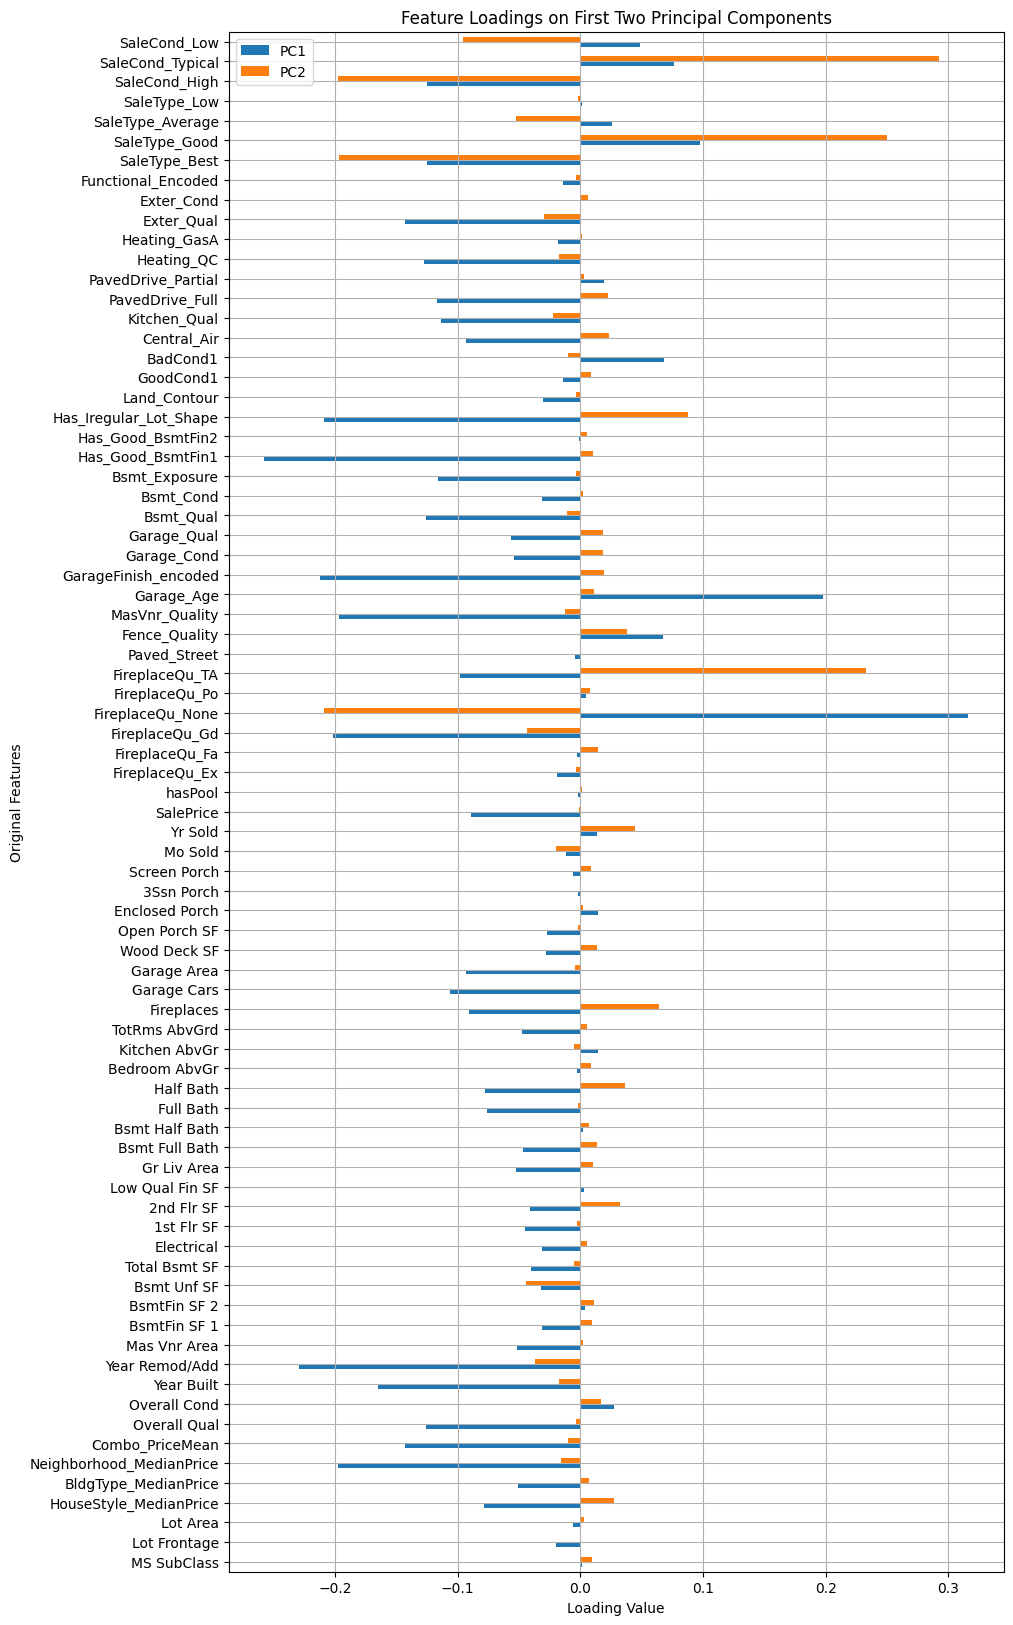

In [22]:
loading_df.plot(kind='barh', figsize=(10, 20))
plt.title("Feature Loadings on First Two Principal Components")
plt.xlabel("Loading Value")      # now X-axis shows loadings
plt.ylabel("Original Features")  # Y-axis shows feature names
plt.grid(True)
plt.show()
